# Parallel Random Circuit Sampling (RCS) & XEB Analysis

This notebook serves as an end-to-end tutorial for generating, executing, and analyzing Random Circuit Sampling (RCS) experiments using the framework within ReCirq. Because full-chip quantum simulations are computationally expensive, this guide demonstrates how to use local verification on smaller sub-grids to calculate overall system performance for noisy simulation.

Throughout this notebook, we will walk through the following core workflow:

* **Defining Qubit Patches:** Partitioning a larger system into disjoint, non-overlapping sub-grids.
* **Configuring the Noiseless Simulation:** Executing a noiseless simulation to establish ideal Cross-Entropy Benchmarking (XEB) fidelities.
* **Configuring the Noisy Simulation via QVM:** Utilizing the Quantum Virtual Machine configured with realistic device noise properties to simulate actual hardware execution.
* **Analyzing & Visualizing Results:** Calculating individual patch fidelities and total system fidelity for noisy simulations, and plotting the results to show fidelity decay caused by accumulated noise.

In [2]:
# To run this notebook in Google Colab, uncomment and run the following line:
#!pip install cirq cirq_google qsimcirq

# To install the local 'recirq' package from the repository:
# 1. Clone the repo: !git clone https://github.com/quantumlib/ReCirq.git
# 2. Install: !pip install -e ReCirq/
# 3. IMPORTANT: Restart the Colab runtime (Runtime > Restart session) after installation.

# Imports

In [ ]:
import cirq
import cirq_google
import qsimcirq
import recirq.random_circuit_sampling as rcs
import matplotlib.pyplot as plt
import numpy as np

# Noiseless Simulation

## Define the patches

Patches serve as a tool for local verification and benchmarking. By partitioning the processor into non-overlapping sub-grids, we can use classical simulators to compute exact ideal states that would be computationally impossible at full-chip scale. This also allows us to characterize local noise profiles within specific hardware regions. Finally, we can estimate the overall fidelity of the larger system by calculating the product of the fidelities from these independent patches.

Select sets of connected qubits to serve as patches. These patches must be disjoint and should not share any common qubits.

In [ ]:
patch_1 = cirq.GridQubit.rect(4, 3, top=0, left=0)
patch_2 = cirq.GridQubit.rect(4, 3, top=0, left=3)
patch_3 = cirq.GridQubit.rect(4, 3, top=4, left=0)
patches = [patch_1, patch_2, patch_3]

## Set up and run the experiment

Specify the qubit patches and the desired circuit depths for XEB calculation. Additionally, define the number of random circuit instances per configuration and the specific tiling pattern for the experiment. While the framework supports characterizing the $fSim$ gate parameters ($\theta, \phi, \zeta, \chi, \gamma$), this step is bypassed here as we are performing an ideal noiseless simulation.

In [ ]:
experiment = rcs.RCSExperiment(
    patches=patches,
    depths=[30, 50, 70, 90],
    num_instances=3,
    pattern_name="staggered",
    seed= 2026
)

In [ ]:
results = experiment.run(sampler=cirq.Simulator(), n_repetitions=10000, characterize=False)

## Calculate linear XEB fidelities

To calculate fidelities via noiseless simulation, we can employ the standard `cirq.Simulator()`. Here, we use the performance-optimized `qsimcirq.QSimSimulator()` to improve execution efficiency.


In [ ]:
fidelities = results.fidelities_lin(simulator=qsimcirq.QSimSimulator())

## Plot the results

Visualize the XEB results for each patch across the specified circuit depths. The plot reflects the mean fidelity calculated across all random circuit instances for each (patch, depth) configuration.

Note on ideal vs. noisy simulation: You might notice that the plotted linear XEB fidelity is flat at around 1.0 across all circuit depths. This behavior is exactly what we expect from an ideal, noiseless simulation. In a real quantum hardware experiment (or a noisy simulation), incoherent errors and decoherence accumulate at each gate layer, resulting in a characteristic exponential decay curve as the circuit gets deeper. Since our simulated qubits do not suffer from any noise, the fidelity remains at ~1.0 (with microscopic fluctuations resulting purely from finite sampling variance across our 10,000 repetitions). See the next section for noisy simulation.

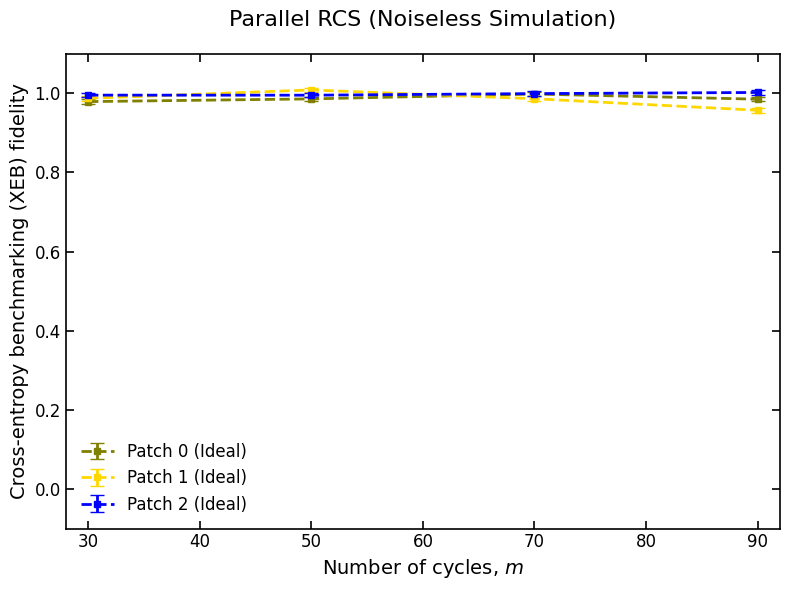

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['olive', 'gold', 'blue']

total_samples_noiseless = experiment.num_instances * 10000
err_val_noiseless = 1.0 / np.sqrt(total_samples_noiseless)

means_matrix_noiseless = np.array([[np.mean(fidelities[(i, d)]) for d in experiment.depths] for i in range(len(patches))])
errs_matrix_noiseless = np.full_like(means_matrix_noiseless, err_val_noiseless)

for i in range(len(patches)):
    ax.errorbar(
        experiment.depths,
        means_matrix_noiseless[i],
        yerr=errs_matrix_noiseless[i],
        marker='s',
        markersize=4,
        linewidth=2,
        label=f'Patch {i} (Ideal)',
        linestyle='--',
        capsize=5,
        color=colors[i]
    )

ax.set_ylim(-0.1, 1.1)
ax.set_xlim(min(experiment.depths) - 2, max(experiment.depths) + 2)
ax.set_xlabel(r'Number of cycles, $m$', fontsize=14)
ax.set_ylabel('Cross-entropy benchmarking (XEB) fidelity', fontsize=14)
ax.set_title('Parallel RCS (Noiseless Simulation)', fontsize=16, pad=20)
ax.legend(frameon=False, fontsize=12)
ax.tick_params(
    axis='both',
    direction='in',
    top=True,
    right=True,
    labelsize=12,
    width=1.2,
    length=6
)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
plt.tight_layout()
plt.show()

# Noisy simulation with quantum virtual machine

We perform noisy simulations using the [Quantum Virtual Machine (QVM)](https://quantumai.google/cirq/simulate/quantum_virtual_machine) to account for device-specific connectivity and calibration-based noise profiles. The resulting XEB fidelity plot demonstrates the fidelity decay as circuit depth increases, reflecting the accumulation of errors in a noisy system.

In [ ]:
processor_id = "weber"
noise_props = cirq_google.engine.load_device_noise_properties(processor_id)
noise_model = cirq_google.NoiseModelFromGoogleNoiseProperties(noise_props)
qvm_sampler = cirq.DensityMatrixSimulator(noise=noise_model)
device = cirq_google.engine.create_device_from_processor_id(processor_id)
print(device)

                                             (0, 5)───(0, 6)
                                             │        │
                                             │        │
                                    (1, 4)───(1, 5)───(1, 6)───(1, 7)
                                    │        │        │        │
                                    │        │        │        │
                                    (2, 4)───(2, 5)───(2, 6)───(2, 7)───(2, 8)
                                    │        │        │        │        │
                                    │        │        │        │        │
                  (3, 2)───(3, 3)───(3, 4)───(3, 5)───(3, 6)───(3, 7)───(3, 8)───(3, 9)
                  │        │        │        │        │        │        │        │
                  │        │        │        │        │        │        │        │
         (4, 1)───(4, 2)───(4, 3)───(4, 4)───(4, 5)───(4, 6)───(4, 7)───(4, 8)───(4, 9)
         │        │        │        │        │        │   

In [ ]:
patch_1_on_device = [
    cirq.GridQubit(4, 1), cirq.GridQubit(4, 2), cirq.GridQubit(4, 3),
    cirq.GridQubit(5, 1), cirq.GridQubit(5, 2), cirq.GridQubit(5, 3),
    cirq.GridQubit(6, 1), cirq.GridQubit(6, 2), cirq.GridQubit(6, 3)
]

patch_2_on_device = [
    cirq.GridQubit(1, 4), cirq.GridQubit(1, 5), cirq.GridQubit(1, 6),
    cirq.GridQubit(2, 4), cirq.GridQubit(2, 5), cirq.GridQubit(2, 6),
    cirq.GridQubit(3, 4), cirq.GridQubit(3, 5), cirq.GridQubit(3, 6)
]

patch_3_on_device = [
    cirq.GridQubit(4, 4), cirq.GridQubit(4, 5), cirq.GridQubit(4, 6),
    cirq.GridQubit(5, 4), cirq.GridQubit(5, 5), cirq.GridQubit(5, 6),
    cirq.GridQubit(6, 4), cirq.GridQubit(6, 5), cirq.GridQubit(6, 6)
]

patches_on_device = [patch_1_on_device, patch_2_on_device, patch_3_on_device]

In [ ]:
noisy_experiment = rcs.RCSExperiment(
    patches=patches_on_device,
    depths=[10, 12, 14, 16, 18, 20],
    num_instances=3,
    pattern_name="staggered",
    seed= 2026
)

In [ ]:
n_repetitions = 10000
noisy_results = noisy_experiment.run(
    sampler = qvm_sampler,
    n_repetitions = n_repetitions
)

noisy_fidelities = noisy_results.fidelities_lin(simulator=qsimcirq.QSimSimulator())

The figure below illustrates the measured linear XEB fidelities for the separate patches. It also shows the estimated total system fidelity computed by multiplying the fidelities of those individual patches.

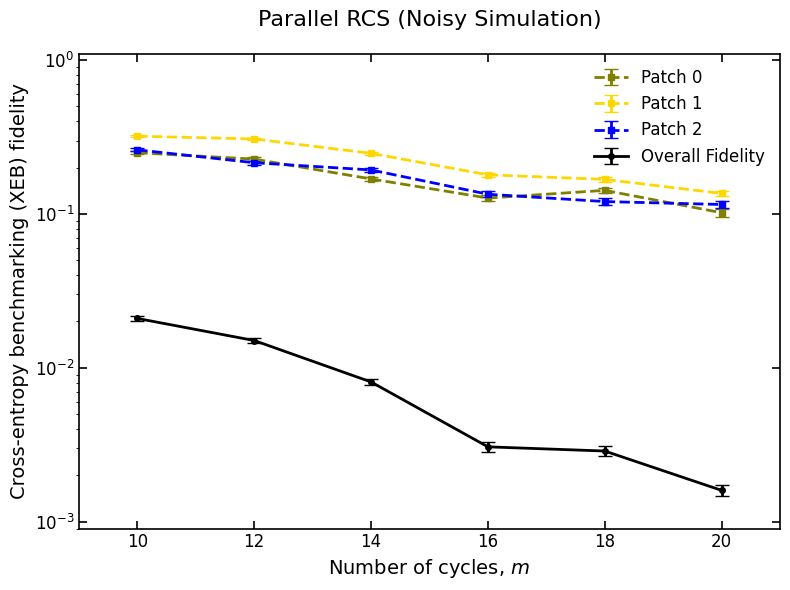

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['olive', 'gold', 'blue']

depths = noisy_experiment.depths
num_patches = len(patches_on_device)
num_instances = noisy_experiment.num_instances

total_samples = num_instances * n_repetitions
err_val = 1.0 / np.sqrt(total_samples)

means_matrix = np.zeros((num_patches, len(depths)))
errs_matrix = np.zeros((num_patches, len(depths)))


for i in range(num_patches):
    y_means = []
    y_errs = []
    for j, d in enumerate(depths):
        fids = noisy_fidelities[(i, d)]
        mean_val = np.mean(fids)
        y_means.append(mean_val)
        y_errs.append(err_val)
        means_matrix[i, j] = mean_val
        errs_matrix[i, j] = err_val
    ax.errorbar(depths, y_means, yerr=y_errs, marker='s', markersize=4,
                linewidth=2, label=f'Patch {i}', linestyle='--', capsize=5, color = colors[i])


overall_means = []
overall_errs = []


for j in range(len(depths)):
    f_tot = np.prod(means_matrix[:, j])
    overall_means.append(f_tot)
    rel_errors_sq = (errs_matrix[:, j] / means_matrix[:, j])**2
    err_tot = f_tot * np.sqrt(np.sum(rel_errors_sq))
    overall_errs.append(err_tot)

ax.errorbar(depths, overall_means, yerr=overall_errs, marker='o', markersize=4,
            linewidth=2, label='Overall Fidelity', linestyle='solid', color='black', capsize=5)

ax.set_xlim(min(depths) - 2, max(depths) + 2)
ax.set_xlabel(r'Number of cycles, $m$', fontsize=14)
ax.set_ylabel('Cross-entropy benchmarking (XEB) fidelity', fontsize=14)
ax.set_ylim(0.0009, 1.1)
ax.set_xlim(9, 21)
ax.set_yscale('log')
ax.set_title('Parallel RCS (Noisy Simulation)', fontsize=16, pad=20)
ax.legend(frameon=False, fontsize=12)
ax.tick_params(
    axis='both',
    direction='in',
    top=True,
    right=True,
    labelsize=12,
    width=1.2,
    length=6
)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
plt.tight_layout()
plt.show()

## Conclusion
In this tutorial, we successfully demonstrated the workflow for running a Random Circuit Sampling (RCS) experiment within the ReCirq framework. By dividing the quantum processor into independent, non-overlapping patches, we were able to efficiently estimate the performance of a larger system without the massive computational overhead of a large-system simulation.

The final visualizations illustrate the expected behavior of noisy quantum execution: as the depth of the random circuits increases, the Cross-Entropy Benchmarking (XEB) fidelity decays. This decay reflects the accumulation of gate errors over time. Finally, this patching and cross-entropy analysis provides a scalable method for characterizing and benchmarking the performance of near-term quantum devices.